In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [6]:
Data = pd.read_excel("Similiar_UAV.xlsx")
Data = Data[Data["Fuselage Length (m)"].isna() == False]
Data

,Name,Range (km),Endurance (hr),Cruise Speed (m/s),MTOW (kg),Payload Weight (kg),Empty Weight (kg),Battery Weight (kg),Wing Span (m),Wing Area (m^2),Fuselage Length (m),Aspect Ratio,Tip Chord (mm),Root Chord (mm),Taper Ratio
0,Yangda Mapird Pro,114.444,1.87,17.0,7.5,1.14,4.00,2.36,2.10,0.50,1.20,8.820000,NaN,NaN,NaN
1,Yangda Mapird Plus,-,2.23,20.0,11.5,1.50,5.00,4.72,2.43,0.65,1.40,9.084462,NaN,NaN,
2,Yangda Nim- bus Pro,120.24,1.67,20.0,8.6,2.00,4.03,2.56,1.95,0.46,1.30,8.266304,NaN,NaN,NaN
3,Yangda FW- 250,180,2.00,25.0,12.0,2.00,5.50,4.50,2.50,0.52,1.40,12.019231,41.0,290.0,0.141379
4,Avy Aera,67.896,0.92,20.5,12.0,1.50,6.90,3.60,2.40,0.96,1.30,6.000000,166.0,578.0,0.287197
5,Foxtech Baby Shark 260,198,2.50,22.0,13.0,2.10,5.60,5.30,2.50,0.50,1.44,12.500000,35.0,295.0,0.118644
6,P330 Pro,201.852,2.67,21.0,14.0,2.00,6.30,5.70,2.53,0.56,1.21,11.430179,45.0,301.0,0.149502
7,Foxtech AYK-250,374.4,4.00,26.0,15.0,2.20,7.40,5.40,2.50,0.50,1.26,12.500000,50.0,277.0,0.180505
8,Wingcopter 178,100,1.50,42.0,18.0,2.00,8.40,7.60,1.78,0.58,1.32,5.462759,NaN,NaN,NaN
9,FlyDragon FLY-2100,200,2.30,18.0,7.0,1.20,3.40,2.40,2.10,0.52,1.20,8.480769,NaN,NaN,NaN


In [7]:
Weights = Data["MTOW (kg)"].to_numpy()
Fuselage_lengths = Data["Fuselage Length (m)"].to_numpy()

np.float64(1.284645476075139)

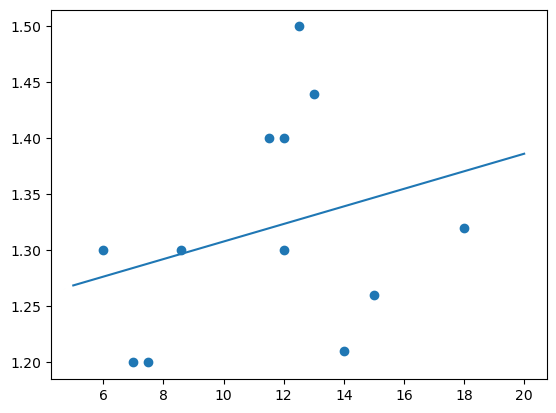

In [12]:
plt.scatter(Weights,Fuselage_lengths)
poly_b, poly_c = np.polyfit(Weights,Fuselage_lengths,1)
x_array = np.linspace(5,20,100)
y_array = poly_b*x_array +poly_c
plt.plot(x_array,y_array)

Our_weight = 7.021
Fuselage_length = poly_b*Our_weight + poly_c
Fuselage_length

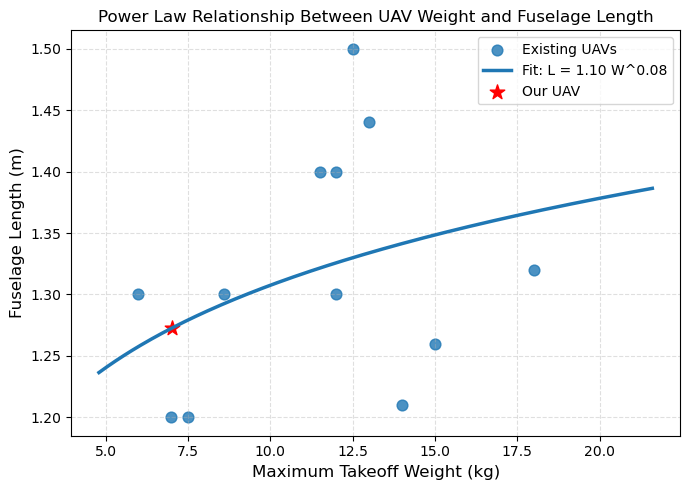

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays if not already
Weights = np.array(Weights)
Fuselage_lengths = np.array(Fuselage_lengths)

# Fit power law in log space
a, b = np.polyfit(np.log(Weights), np.log(Fuselage_lengths), 1)

# Continuous curve
x_array = np.linspace(min(Weights)*0.8, max(Weights)*1.2, 200)
y_array = np.exp(b) * x_array**a

# Your UAV
Our_weight = 7.021
Our_length = np.exp(b) * Our_weight**a

plt.figure(figsize=(7,5))

# Data points
plt.scatter(Weights, Fuselage_lengths,
            s=60, alpha=0.8, label="Existing UAVs")

# Fit curve
plt.plot(x_array, y_array,
         linewidth=2.5,
         label=f"Fit: L = {np.exp(b):.2f} W^{a:.2f}")

# Your UAV point
plt.scatter(Our_weight, Our_length,
            color='red', s=120, marker='*',
            label="Our UAV")

plt.xlabel("Maximum Takeoff Weight (kg)", fontsize=12)
plt.ylabel("Fuselage Length (m)", fontsize=12)
plt.title("Power Law Relationship Between UAV Weight and Fuselage Length")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()

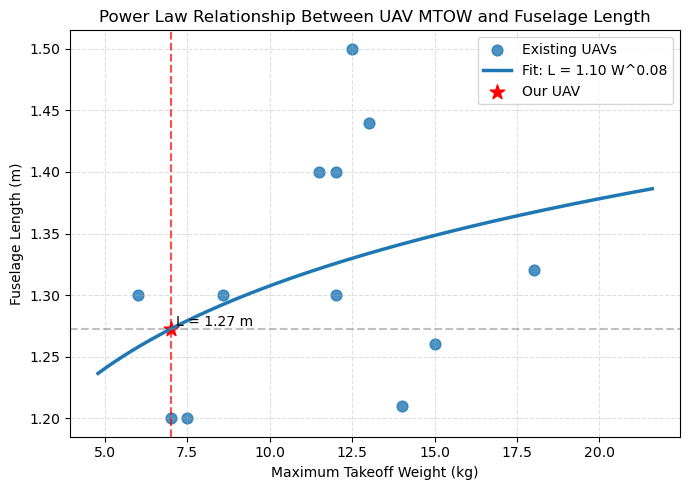

In [14]:
import numpy as np
import matplotlib.pyplot as plt

Weights = np.array(Weights)
Fuselage_lengths = np.array(Fuselage_lengths)

# Power law fit
a, b = np.polyfit(np.log(Weights), np.log(Fuselage_lengths), 1)

# Smooth curve
x_array = np.linspace(min(Weights)*0.8, max(Weights)*1.2, 200)
y_array = np.exp(b) * x_array**a

# Our UAV
Our_weight = 7.021
Our_length = np.exp(b) * Our_weight**a

plt.figure(figsize=(7,5))

# Data points
plt.scatter(Weights, Fuselage_lengths,
            s=60, alpha=0.8, label="Existing UAVs")

# Fit curve
plt.plot(x_array, y_array,
         linewidth=2.5,
         label=f"Fit: L = {np.exp(b):.2f} W^{a:.2f}")

# Our UAV point
plt.scatter(Our_weight, Our_length,
            color='red', s=120, marker='*',
            label="Our UAV")

# Vertical line at our weight
plt.axvline(Our_weight, linestyle="--", color="red", alpha=0.7)

# Horizontal line at predicted length
plt.axhline(Our_length, linestyle="--", color="gray", alpha=0.5)

# Annotate value
plt.text(Our_weight*1.02, Our_length,
         f"L = {Our_length:.2f} m",
         verticalalignment='bottom')

plt.xlabel("Maximum Takeoff Weight (kg)")
plt.ylabel("Fuselage Length (m)")
plt.title("Power Law Relationship Between UAV MTOW and Fuselage Length")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()